# Linear Regression


## Check out the data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [9]:
df= pd.read_csv("Aramco.csv")
df.head(10)

,Date,Close,High,Low,Open,Volume
0,12/11/2019,22.352606,22.352606,22.352606,22.352606,38289394
1,12/12/2019,23.368637,24.575170,22.860623,24.575170,505692621
2,12/15/2019,23.749640,23.813142,23.368630,23.559135,98349281
3,12/16/2019,24.130653,24.194154,23.813145,23.813145,105973907
4,12/17/2019,23.971899,24.225905,23.813145,24.162403,142672245
5,12/18/2019,23.305134,23.876650,23.305134,23.813148,83822621
6,12/19/2019,22.543108,23.336880,22.543108,23.305128,108120197
7,12/22/2019,22.416105,22.670112,22.162099,22.606611,39709972
8,12/23/2019,22.606611,22.638361,22.384355,22.416106,35098090
9,12/24/2019,22.479609,22.670113,22.416106,22.638361,22184338


In [10]:
df['Date'] = pd.to_datetime(df['Date'])
df.dtypes

Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1514 entries, 0 to 1513
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1514 non-null   datetime64[ns]
 1   Close   1514 non-null   float64       
 2   High    1514 non-null   float64       
 3   Low     1514 non-null   float64       
 4   Open    1514 non-null   float64       
 5   Volume  1514 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 71.1 KB


In [12]:
df.describe()

,Date,Close,High,Low,Open,Volume
count,1514,1514.000000,1514.000000,1514.000000,1514.000000,1.514000e+03
mean,2022-12-21 21:29:43.355350272,25.337110,25.479387,25.189289,25.338883,1.083187e+07
min,2019-12-11 00:00:00,17.653475,17.970983,17.145461,17.145461,0.000000e+00
25%,2021-06-14 06:00:00,23.519062,23.603179,23.450534,23.518239,4.466211e+06
50%,2022-12-20 12:00:00,25.181452,25.275131,25.036044,25.167764,7.548395e+06
75%,2024-07-03 18:00:00,27.455824,27.640616,27.272477,27.485013,1.247766e+07
max,2025-12-31 00:00:00,31.935476,32.574183,31.710049,31.935471,6.562831e+08
std,NaN,2.702074,2.735238,2.676777,2.712993,2.391855e+07


In [13]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

# EDA


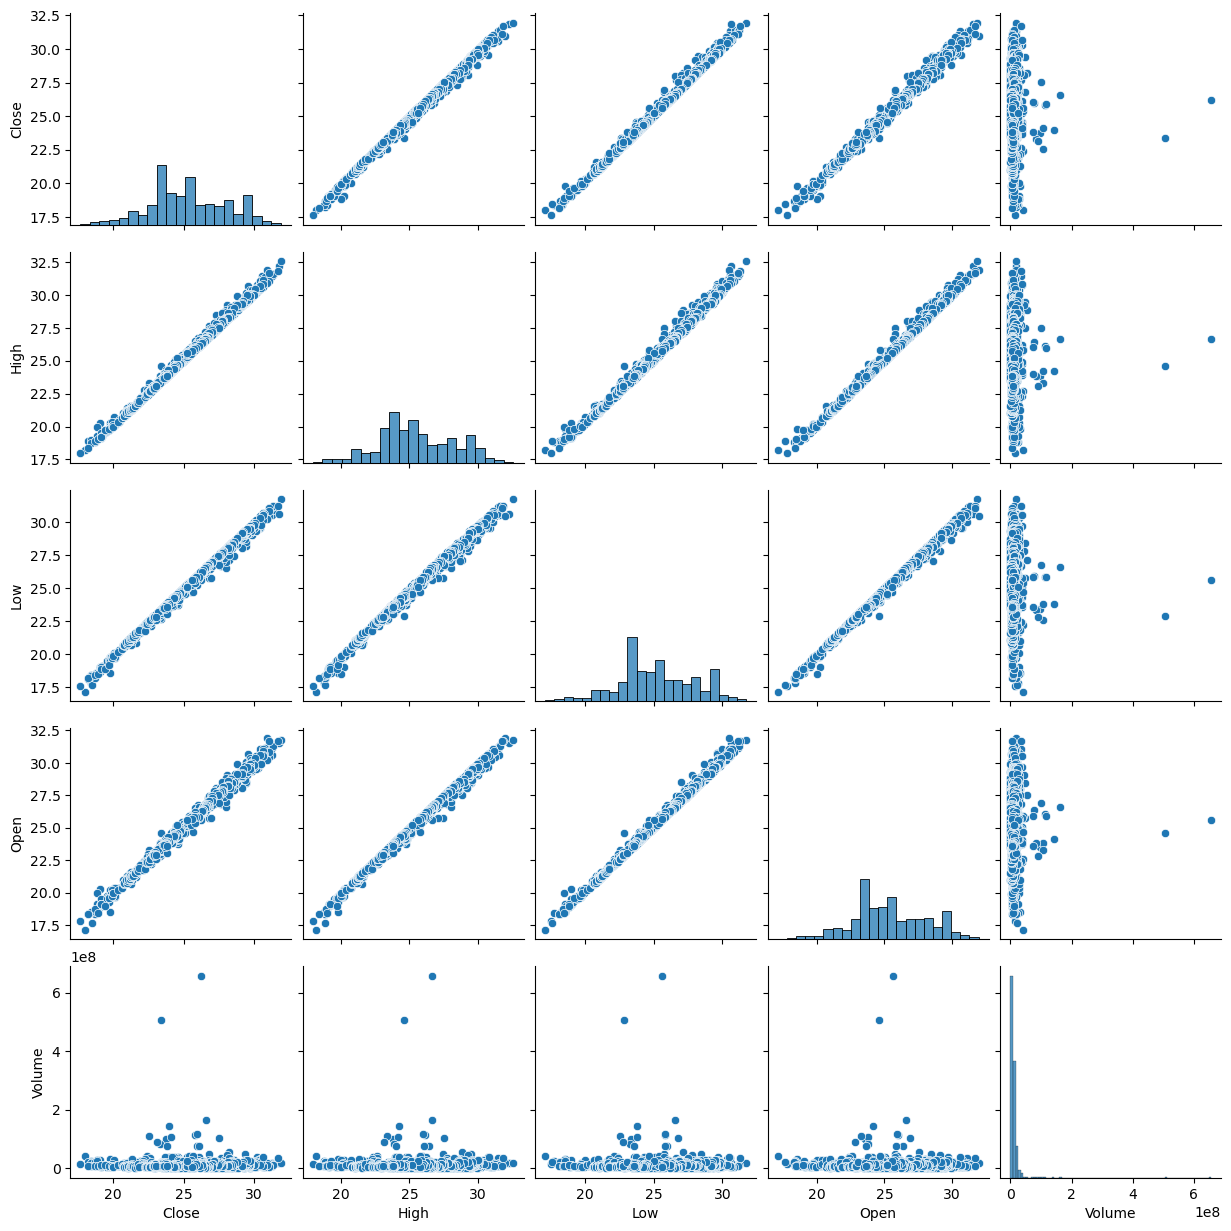

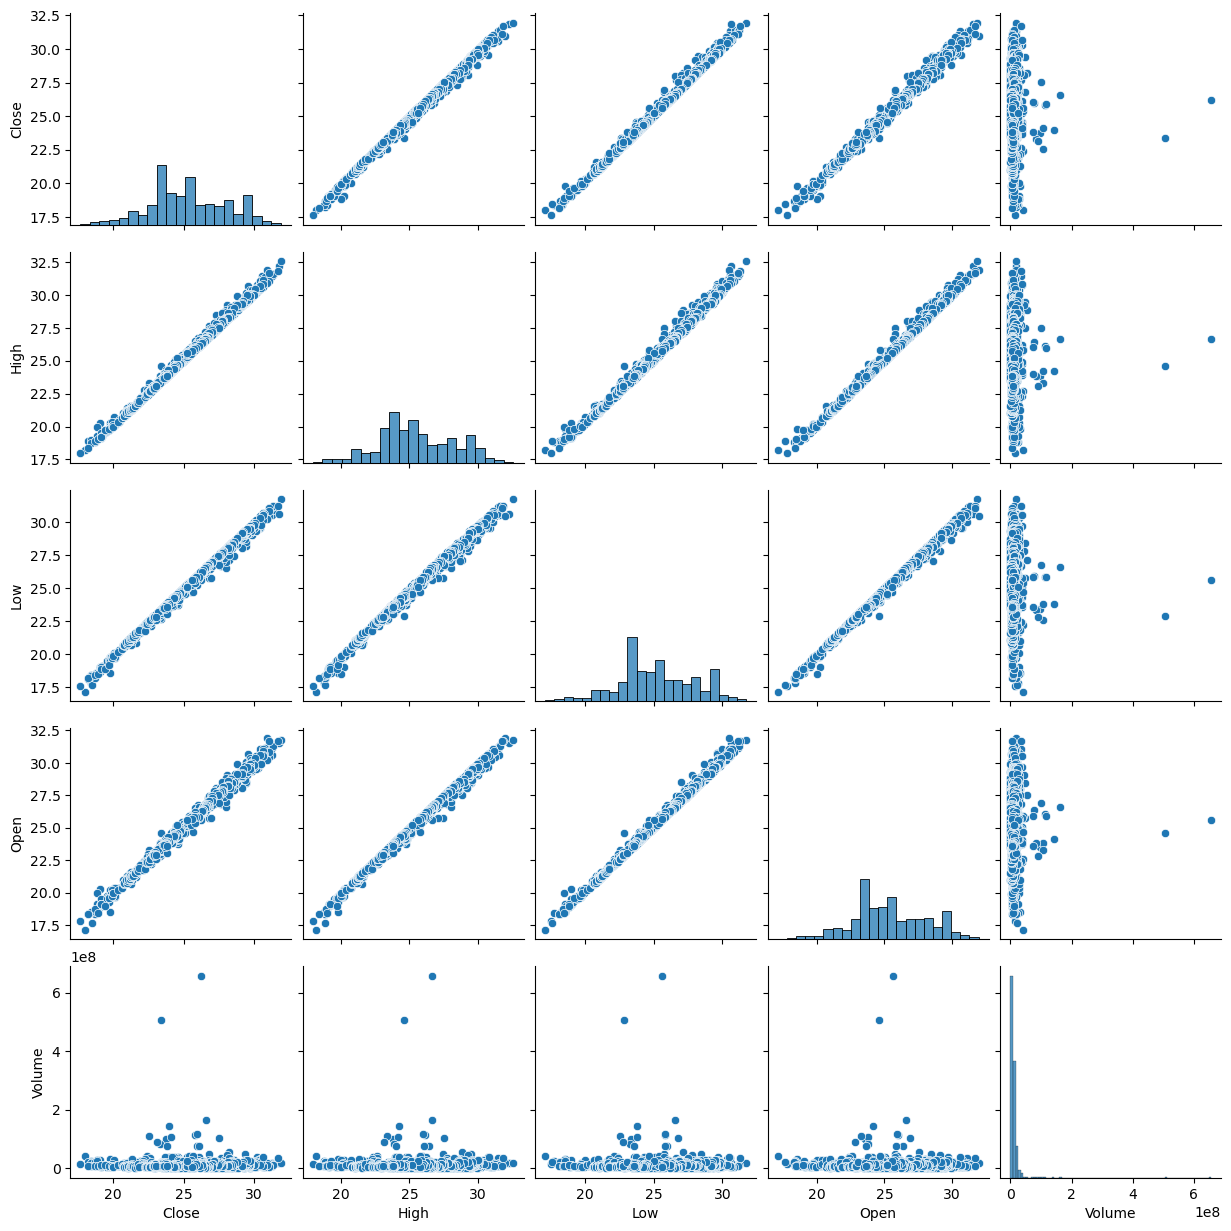

In [14]:
sns.pairplot(df)
plt.show()

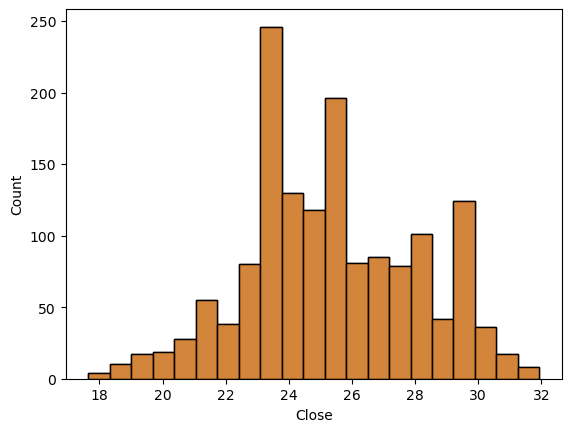

In [16]:
sns.histplot(df['Close'])
plt.show()

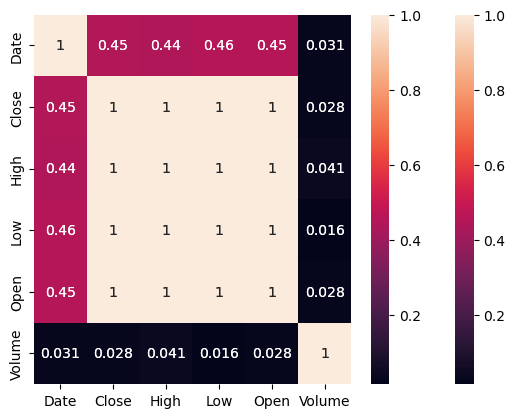

In [18]:
sns.heatmap(df.corr(),annot=True)
plt.show()

## Feature Engineering

In [34]:
df['Price_range'] = df['High'] - df['Low']

In [37]:
df['Close_lag1'] = df['Close'].shift(1)

In [56]:
df.dropna(inplace=True)

## Training a Linear Regression Model
### X and y arrays

In [69]:
X = df[['Open','High','Low','Volume',
        'Price_range',
        'Close_lag1']]

In [58]:
y=df['Close']

## Train Test Split


In [70]:
from sklearn.model_selection import train_test_split

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=101)

## Creating and Training the Model


In [72]:
from sklearn.linear_model import LinearRegression

In [73]:
lm = LinearRegression()

In [74]:
lm.fit(X_train,y_train)

LinearRegression()

## Model Evaluation


In [75]:
print(lm.intercept_)


0.01521576870694119


In [76]:
coeff_df = pd.DataFrame(lm.coef_,X.columns,columns=['Coefficient'])
coeff_df

,Coefficient
Open,-5.229775e-01
High,7.883903e-01
Low,7.628529e-01
Volume,-3.200955e-10
Price_range,2.553741e-02
Close_lag1,-2.897724e-02


## Predictions from our Model


In [77]:
predictions = lm.predict(X_test)

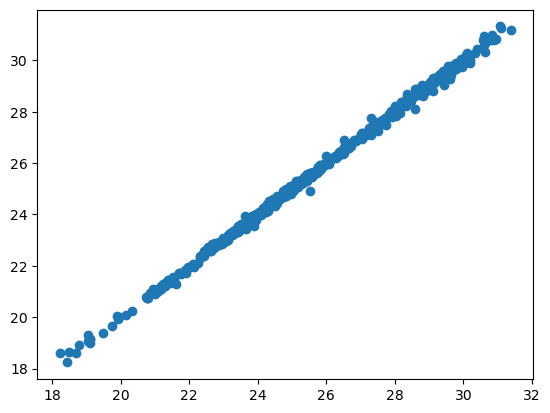

In [78]:
plt.scatter(y_test,predictions)
plt.show()

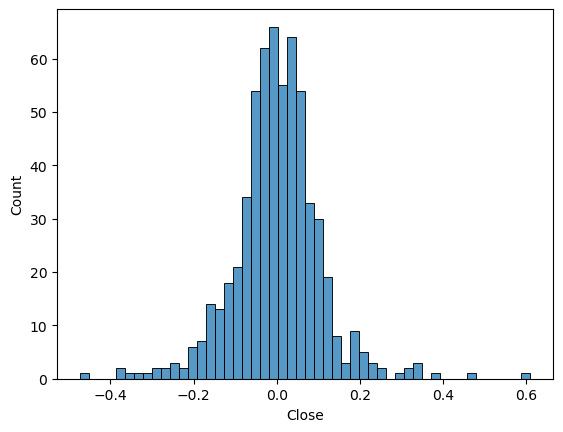

In [79]:
sns.histplot((y_test-predictions),bins=50);
plt.show()

In [80]:
from sklearn import metrics
print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 0.07562540747937743
MSE: 0.01136359981046931
RMSE: 0.10660018672811652
